---
title: "SIR Model"
subtitle: "Rare Event Estimation"
format: 
    html: 
        toc: true
execute: 
  enabled: false
code-annotations: hover
bibliography: "../../references.bib"
jupyter: python3
---

In this example we illustrate how $\texttt{deep\_tensor}$ can be used for a rare event estimation problem associated with a susceptible-infectious-removed (SIR) model. Note that the same problem appears in @Cui2024, where it is described in further detail.

# Problem Setup

We consider a susceptible-infectious-recovered (SIR) model with $K \in \mathbb{N}$ compartments. The percentage of susceptible, infectious and recovered individuals in the $k$-th compartment at time $t \in [0, T]$ are denoted by $S_{k}(t)$, $I_{k}(t)$ and $R_{k}(t)$, respectively. The dynamics of $S_{k}(t)$, $I_{k}(t)$ and $R_{k}(t)$ are governed by the ODEs
$$
\begin{equation}
    \begin{aligned}
        \frac{\mathrm{d}S_{k}}{\mathrm{d}t} &= -\eta_{k}S_{k}I_{k} + \frac{1}{2}\sum_{j \in \mathcal{J}_{k}}(S_{j} - S_{k}), \\
        \frac{\mathrm{d}I_{k}}{\mathrm{d}t} &= \eta_{k}S_{k}I_{k} - \nu_{k}I_{k} + \frac{1}{2}\sum_{j \in \mathcal{J}_{k}}(I_{j} - I_{k}), \\
        \frac{\mathrm{d}R_{k}}{\mathrm{d}t} &= \nu_{k}I_{k} + \frac{1}{2}\sum_{j \in \mathcal{J}_{k}}(R_{j} - R_{k}), 
    \end{aligned}
\end{equation}
$$
where $\mathcal{J}_{k}$ denotes the set of neighbours of the $k$-th compartment, and the parameters $\eta_{k} \in \mathbb{R}$ and $\nu_{k} \in \mathbb{R}$ represent the infection and recovery rates of the $k$-th compartment respectively. 

Following @Cui2024, we consider a setup in which the $k$-th compartment is connected to compartments $k-1$ and $k+1$, and impose periodic boundary conditions such that $(S_{K+1}, I_{K+1}, R_{K+1}) = (S_{1}, I_{1}, R_{1})$ and $(S_{0}, I_{0}, R_{0}) = (S_{K}, I_{K}, R_{K})$. The initial conditions are given by $S_{k}(0)= 99-K+k$, $I_{k}(0) = K+1-k$, $R_{k}(0) = 0$ for $k \in \{1, 2, \dots, K\}$.

## Prior

To parametrise the prior we treat all parameters, $\boldsymbol{\theta} := [\eta_{1}, \nu_{1}, \cdots, \eta_{K}, \nu_{K}]^{\top} \in \mathbb{R}^{2K}$, as uniformly distributed in the hypercube $\Theta := [0, 2]^{2K}$. The prior can therefore be expressed as
$$
    \pi_{\theta}(\boldsymbol{\theta}) \propto \prod_{k=1}^{2K} \mathbb{I}_{[0, 2]}(x_{k}),
$$
where $\mathbb{I}_{[0, 2]}(\cdot)$ denotes the indicator function for the interval $[0, 2]$.

## Likelihood

We assume that we have access to noisy observations of the percentage of infected people in each compartment at time points $t_{j} = 5j/6$, where $j \in \{1, 2, 3, 4, 5, 6\}$, generated under the "true" parameters $\boldsymbol{\theta}_{\mathrm{true}} := [0.1, 1, 0.1, 1, \dots, 0.1, 1]^{\top}$. Each observation is corrupted by independent Gaussian noise; that is,
$$
y_{k, j} = I_{k}(t_{j}; \boldsymbol{\theta}_{\mathrm{true}}) + \epsilon_{k,j}, 
    \quad \epsilon_{k, j} \sim \mathcal{N}(0, 1), 
    \quad k = 1, \dots, K, 
    \quad j = 1, \dots, 6.
$$
Therefore, the likelihood function takes the form
$$
\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y}) \propto 
    \exp\left(-\frac{1}{2}\sum_{k=1}^{K}\sum_{j=1}^{6}\left(I_{k}(t_{j}; \boldsymbol{\theta}) - y_{k,j}\right)^{2}\right),
$$
and the posterior density can be expressed as 
$$
    \pi_{\theta|Y}(\boldsymbol{\theta} | \boldsymbol{y}) = \frac{1}{Z}\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta}), \qquad Z := \int_{\Theta} \mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta}) \, \mathrm{d}\boldsymbol{\theta}.
$$

## Rare Event

We wish to quantify the posterior probability that the percentage of infected people in the final compartment exceeds the threshold $I_{\mathrm{max}} = 88$ at any point in the time interval $t \in [0, 5]$. That is, we aim to quantify the probability $\mathbb{P}_{\pi_{\theta|Y}}(\mathcal{F})$, where the set $\mathcal{F}$ is defined by
$$
    \mathcal{F} := \left\{\boldsymbol{\theta} \,|\, \max_{t \in [0, 5]} I_{K}(t; \boldsymbol{\theta}) > I_{\mathrm{max}}\right\}.
$$

## Rare Event Estimator

To estimate this probability, we can use importance sampling. Following @Cui2024, note that $\mathbb{P}_{\pi_{\theta|Y}}(\mathcal{F})$ can be expressed as
$$
\begin{align}
    \mathbb{P}_{\pi_{\theta|Y}}(\mathcal{F}) &= \frac{1}{Z}\int_{\Theta}\mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta})\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta}) \, \mathrm{d}\boldsymbol{\theta} \\ 
    &= \frac{\mathbb{E}_{\pi_{\theta}}[\mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta})\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})]}{\mathbb{E}_{\pi_{\theta}}[\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})]} \\ 
    &= \frac{\mathbb{E}_{p}[\mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta})\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta})/p(\boldsymbol{\theta})]}{\mathbb{E}_{q}[\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{X}(\boldsymbol{\theta})/q(\boldsymbol{\theta})]},
\end{align}
$$ {#eq-prob-ratio}
where $\mathbb{I}_{\mathcal{F}}(\cdot)$ denotes the indicator function of the set $\mathcal{F}$, and $p(\cdot)$ and $q(\cdot)$ are importance densities that satisfy $\mathrm{supp}(\mathbb{I}_{\mathcal{F}}\cdot\pi_{\theta|Y}) \subseteq \mathrm{supp}(p)$ and $\mathrm{supp}(\pi_{\theta|Y}) \subseteq \mathrm{supp}(q)$. An unbiased importance sampling estimator for the numerator of @eq-prob-ratio takes the form
$$
    Q_{N} := \frac{1}{N}\sum_{i=1}^{N} \mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta}^{(i)})\mathcal{L}(\boldsymbol{\theta}^{(i)}; \boldsymbol{y}) \frac{\pi_{\theta}(\boldsymbol{\theta}^{(i)})}{p(\boldsymbol{\theta}^{(i)})}, \qquad \{\boldsymbol{\theta}^{(i)}\}_{i=1}^{N} \sim p(\cdot).
$$
Similarly, an unbiased importance sampling estimator for the denominator of @eq-prob-ratio takes the form
$$
    Z_{N} := \frac{1}{N}\sum_{i=1}^{N} \mathcal{L}(\boldsymbol{\theta}^{(i)}; \boldsymbol{y}) \frac{\pi_{\theta}(\boldsymbol{\theta}^{(i)})}{q(\boldsymbol{\theta}^{(i)})}, \qquad \{\boldsymbol{\theta}^{(i)}\}_{i=1}^{N} \sim q(\cdot).
$$
The corresponding estimator for the rare event probability, denoted by $\hat{\mathbb{P}}_{\pi_{\theta|Y}}(\mathcal{F})$, takes the form
$$
\begin{equation}
    \mathbb{P}_{\pi_{\theta|Y}}(\mathcal{F}) \approx \hat{\mathbb{P}}_{\pi_{\theta|Y}}(\mathcal{F}) := \frac{Q_{N}}{Z_{N}}.
\end{equation}
$$
We note that this estimator is biased (it is a ratio of two unbiased estimators); however, this bias is negligible when a large, finite sample size is used [@Cui2024]. Choosing appropriate importance densities can significantly reduce the variance of the estimator $R_{N}$. In particular, the optimal choices for densities $p(\cdot)$ and $q(\cdot)$, denoted by $p^{*}(\cdot)$ and $q^{*}(\cdot)$ respectively, take the form
$$
    p^{*}(\boldsymbol{\theta}) := \frac{\mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta})\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta})}{\int_{\Theta}\mathbb{I}_{\mathcal{F}}(\boldsymbol{\theta}')\mathcal{L}(\boldsymbol{\theta}'; \boldsymbol{y})\pi_{\theta}(\boldsymbol{\theta}') \, \mathrm{d}\boldsymbol{\theta}'}, \qquad q^{*}(\boldsymbol{\theta}) := \frac{\mathcal{L}(\boldsymbol{\theta}; \boldsymbol{y}) \pi_{\theta}(\boldsymbol{\theta})}{\int_{\Theta}\mathcal{L}(\boldsymbol{\theta}'; \boldsymbol{y}) \pi_{\theta}(\boldsymbol{\theta}') \, \mathrm{d}\boldsymbol{\theta}'}.
$$
We note that the density $q^{*}(\cdot)$ coincides with the posterior density. When $p^{*}(\cdot)$ and $q^{*}(\cdot)$ are used, they produce a zero-variance estimate of the rare event probability. However, we do not have access to these densities in general. Instead, we approximate them using the DIRT algorithm, with the aim of constructing an estimator with low variance.

# Implementation in $\texttt{deep\_tensor}$

We begin by importing the relevant libraries.

In [13]:
from pathlib import Path
from typing import Tuple

from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde
import torch 
from torch import Tensor

import deep_tensor as dt

from examples.plotting import add_arrows, set_plot_style
from examples.sir import SIRCompartmentModel, build_periodic_adjacency

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_device(device)
torch.manual_seed(0)

plot_path = Path().parent.joinpath("plots")
set_plot_style()

## The Structure of the Posterior

Prior to computing any rare event probabilities, we will take a look at the form of the posterior for a model with three compartments (posteriors for models with more compartments look structurally similar).

We start by initialising the forward model.

In [ ]:
num_compartments = 3
dim = 2 * num_compartments

adjacency_matrix = build_periodic_adjacency(num_compartments)

S0 = torch.arange(100-num_compartments, 100)
I0 = 100 - S0
R0 = torch.zeros((num_compartments,))

t1 = 5.0
t_eval = torch.linspace(0, 5, 25*6+1)
inds_obs = torch.arange(0, 25*6+1, 25)

model = SIRCompartmentModel(adjacency_matrix, S0, I0, R0, t_eval, inds_obs)

Next, we specify the true parameters and generate the observed data.

In [ ]:
true_param = torch.tensor([[0.1, 1.0] * num_compartments])
ys_obs = model.get_obs(model.solve(true_param))
std_noise = 1.0

Next, we specify a function that evaluates the negative logarithm of the (unnormalised) posterior. Note that we do not need to add the contribution of the prior here (the prior is uniform and the preconditioning mapping will be constructed such that the domain of the DIRT approximation coincides with the support of the prior).

In [ ]:
def eval_neglogpost(xs: Tensor) -> Tensor:
    ys = model.get_obs(model.solve(xs))
    neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
    return neglogliks

Finally we can construct a DIRT approximation to the posterior.

In [ ]:
target_func = dt.TargetFunc(eval_neglogpost)

domain = dt.BoundedDomain([-3.0, 3.0])
reference = dt.GaussianReference(domain)
bounds = torch.tensor([[0.0, 2.0]] * dim)
preconditioner = dt.UniformMapping(bounds=bounds, reference=reference)

basis = dt.Lagrange1(num_elems=17)
tt_options = dt.TTOptions(tt_method="fixed_rank", init_rank=7, verbose=0)
tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt)

betas = torch.logspace(-3.0, 0.0, 10)
bridge = dt.Tempering(betas)

dirt_options = dt.DIRTOptions(verbose=0)

dirt_post = dt.DIRT(
    target_func, preconditioner, ftt, bridge, 
    options=dirt_options
)

We can now investigate the geometry of the posterior. @fig-posterior shows a pairplot of the posterior density estimated using $500,000$ samples obtained by running an independence MCMC sampler that uses the DIRT approximation to the posterior as the proposal density.

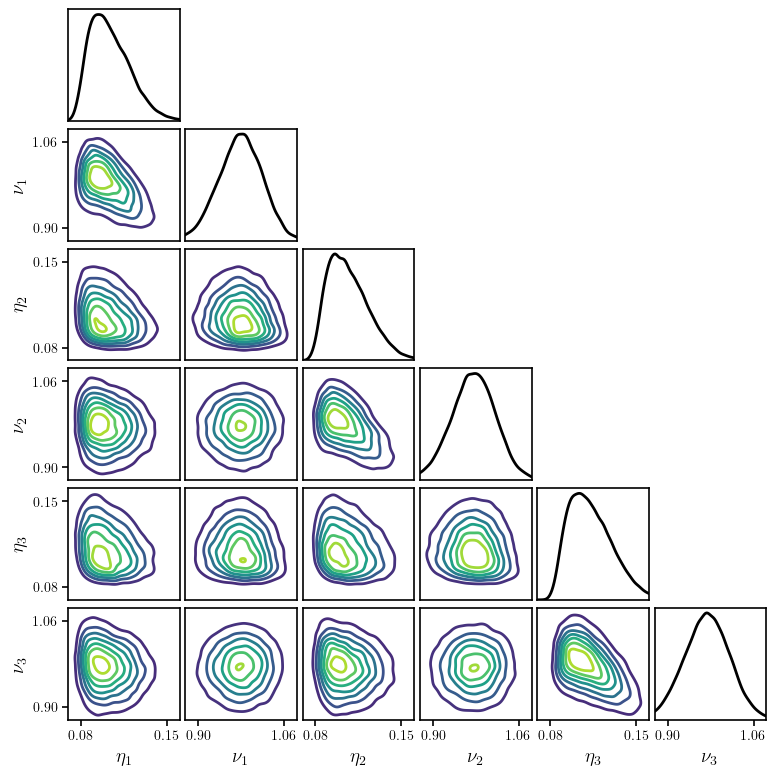

In [ ]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A pair plot of the posterior density of the SIR model with three compartments, estimated using $500,000$ samples from the posterior.
#| label: fig-posterior

num_samples = 100_000

rs = dirt_post.reference.random(n=num_samples, d=dim)                   # <1>
xs, neglogfxs_dirt = dirt_post.eval_irt(rs)                             # <2>
neglogfxs_exact = eval_neglogpost(xs)                                   # <3>
res = dt.run_independence_sampler(xs, neglogfxs_dirt, neglogfxs_exact)  # <4>
xs = res.xs[0, ::2, :]                                                  # <5>

fig, axes = plt.subplots(nrows=xs.shape[1], ncols=xs.shape[1], figsize=(8, 8))
ticks = [
    [0.08, 0.15], 
    [0.90, 1.06],
    [0.08, 0.15], 
    [0.90, 1.06],
    [0.08, 0.15], 
    [0.90, 1.06]
]
dxs = [t[1]-t[0] for t in ticks]
bounds = [
    [ticks[i][0]-0.15*dxs[i], ticks[i][1]+0.15*dxs[i]]
    for i in range(dim)
]

n = 100

for i in range(xs.shape[1]):
    for j in range(i):

        xis, xjs = xs[:, j], xs[:, i]
        data = torch.vstack((xis, xjs))

        kde = gaussian_kde(data.numpy())

        is_ = torch.linspace(bounds[j][0], bounds[j][1], n).tile(n, 1)
        js_ = torch.linspace(bounds[i][0], bounds[i][1], n).tile(n, 1).T
        ijs = torch.vstack((is_.flatten(), js_.flatten()))
        zs = kde(ijs.numpy()).reshape(n, n)

        axes[i][j].contour(is_, js_, zs)

        axes[i][j].set_yticks(ticks[i])
        axes[i][j].set_xticks(ticks[j])
        axes[i][j].set_xlim(bounds[j])
        axes[i][j].set_ylim(bounds[i])

for ax in axes.flat:
    ax.set_box_aspect(1)

for i in range(xs.shape[1]):
    for j in range(i+1):
        if j > 0 or i == 0:
            axes[i][j].set_yticks([])
        if i != dim - 1:
            axes[i][j].set_xticks([])

for i in range(xs.shape[1]):
    kde = gaussian_kde(xs[:, i].numpy())
    is_ = torch.linspace(bounds[i][0], bounds[i][1], n)
    axes[i][i].plot(is_, kde(is_), c="k")
    axes[i][i].set_xlim(bounds[i])
    axes[i][i].set_ylim(bottom=0.0)
axes[dim-1][dim-1].set_xticks(ticks[dim-1])

for i in range(xs.shape[1]):
    for j in range(i+1, dim):
        axes[i][j].set_axis_off()

for i in range(dim):
    label = (r"$\eta_{" if i%2==0 else r"$\nu_{") + f"{(i+2)//2}" + r"}$"
    if i > 0:
        axes[i][0].set_ylabel(label)
    axes[dim-1][i].set_xlabel(label)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.05)

save_path = plot_path.joinpath("posterior.pdf").resolve()
plt.savefig(save_path)

1. Generate a set of samples from the reference density
2. Apply the inverse Rosenblatt transport such that the samples are distributed according to the DIRT approximation to the posterior
3. Evaluate the negative logarithm of the unnormalised posterior density at each sample
4. Run an independence MCMC sampler
5. Thin the generated Markov chain by discarding every second sample

## Rare Event Benchmark

We now investigate the quality of DIRT approximations to the optimal biasing densities for estimating the numerator and denominator of the rare event probability, over a range of rare event thresholds. Our results will look similar to Figure 2 of @Cui2024, in which the same experiment is carried out.

In [ ]:
I_max = 88.0

t1 = 5.0
t_eval = torch.linspace(0, 5, 25*6+1)
inds_obs = torch.arange(0, 25*6+1, 25)

In [ ]:
basis = dt.Lagrange1(num_elems=16)                                          # <1>
tt_options = dt.TTOptions(tt_method="fixed_rank", init_rank=7, verbose=0)
tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt, num_error_samples=0)

domain = dt.BoundedDomain([-3.0, 3.0])                                      # <2>
reference = dt.GaussianReference(domain)

betas = torch.logspace(-4.0, 0.0, 13)                                       # <3>
gamma_prime = 3.3e+3 / I_max
gammas = betas * gamma_prime
bridge_numer = dt.GaussianSmoothing(gammas, betas)
bridge_denom = dt.Tempering(betas)

dirt_options = dt.DIRTOptions(num_error_samples=0, verbose=0)

1. Define the characteristics of the underlying functional tensor train approximation used to construct each layer of the DIRT approximation
2. Define the (Gaussian) reference density
3. Define the parameters associated with the bridging densities

In [ ]:
compartments = [3, 5, 6, 8, 12, 16]
dims = [2*c for c in compartments]

num_compartments = len(compartments)
num_runs = 10
num_samples = 10_000

probs = torch.zeros(num_compartments, num_runs)
num_evals = torch.zeros_like(probs)
dhell_numerators = torch.zeros_like(probs)
dhell_denominators = torch.zeros_like(probs)

In [ ]:
for i, num_compartments in enumerate(compartments):

    print(f"compartments: {num_compartments}")

    dim = 2 * num_compartments

    adjacency_matrix = build_periodic_adjacency(num_compartments)               # <1>
    S0 = torch.arange(100-num_compartments, 100)
    I0 = 100 - S0
    R0 = torch.zeros(num_compartments)

    model = SIRCompartmentModel(adjacency_matrix, S0, I0, R0, t_eval, inds_obs)

    true_param = torch.tensor([[0.1, 1.0] * num_compartments])                  # <2>
    std_noise = 1.0
    ys_true = model.get_obs(model.solve(true_param))
    ys_obs = ys_true + std_noise * torch.randn_like(ys_true)

    def eval_neglogpost(xs: Tensor) -> Tensor:                                  # <3>
        ys = model.get_obs(model.solve(xs))
        neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
        return neglogliks

    def eval_rare_event(xs: Tensor) -> Tuple[Tensor, Tensor]:                   # <4>
        ys_full = model.solve(xs)
        ys = model.get_obs(ys_full)
        neglogliks = (ys-ys_obs).square().sum(dim=1) / (2*std_noise**2)
        Fs = model.response_func(ys_full)
        return neglogliks, Fs

    bounds = torch.tensor([[0.0, 2.0]] * dim)                                   # <5>
    preconditioner = dt.UniformMapping(bounds=bounds, reference=reference)

    for j in range(num_runs):

        target_numer = dt.RareEventFunc(eval_rare_event, threshold=I_max)
        dirt_numer = dt.DIRT(
            target_numer, preconditioner, ftt, bridge_numer, 
            options=dirt_options
        )
        target_denom = dt.TargetFunc(eval_neglogpost)
        dirt_denom = dt.DIRT(
            target_denom, preconditioner, ftt, bridge_denom, 
            options=dirt_options
        )

        rs = dirt_numer.reference.random(num_samples, dim)                      # <6>
        xs, neglogfxs_dirt = dirt_numer.eval_irt(rs)                            # <7>
        neglogfxs_exact = target_numer(xs)                                      # <8>
        dhell_numerator = dt.estimate_dhell(neglogfxs_dirt, neglogfxs_exact)    # <9>

        Q_is = dt.run_importance_sampling(neglogfxs_dirt, neglogfxs_exact)      # <10>
        Q_n = Q_is.log_weights.exp().mean()

        rs = dirt_denom.reference.random(num_samples, dim)                      # <11>
        xs, neglogfxs_dirt = dirt_denom.eval_irt(rs)
        neglogfxs_exact = eval_neglogpost(xs)
        dhell_denominator = dt.estimate_dhell(neglogfxs_dirt, neglogfxs_exact)

        Z_is = dt.run_importance_sampling(neglogfxs_dirt, neglogfxs_exact)
        Z_n = Z_is.log_weights.exp().mean()

        probs[i][j] = Q_n / Z_n
        num_evals[i][j] = (
            dirt_numer.num_eval_construction 
            + dirt_denom.num_eval_construction
        )
        dhell_numerators[i][j] = dhell_numerator
        dhell_denominators[i][j] = dhell_denominator

1. Specify the adjacency matrix and boundary conditions
2. Generate synthetic data by running the forward model with the 'true' values of the parameters
3. Define a function that returns the negative logarithm of the (unnormalised) posterior density. Note that we do not need to add the contribution of the prior here (the prior is uniform and the preconditioning mapping will be constructed such that the domain of the DIRT approximation coincides with the support of the prior).
4. Define a function that return the negative logarithm of the (unnormalised) posterior density, and the parameter-to-event mapping
5. Define a preconditioning mapping that couples the reference density with the (uniform) prior density
6. Generate a set of samples from the reference density
7. Apply the inverse Rosenblatt transport such that the samples are distributed according to the DIRT approximation to the target density
8. Evaluate the negative logarithm of the (unnormalised) target density at each of the transformed samples
9. Estimate the Hellinger divergence between the DIRT density and the actual density
10. Compute the estimate $Q_{N}$
11. Repeat the above process to compute $Z_{N}$

We can now plot the results; these are shown in @fig-estimates.

In [ ]:
#| code-fold: true
#| fig-align: center
#| fig-cap: Estimates of the Hellinger distance between the optimal importance densities and the DIRT approximations (left), estimates of the rare event probabilities (centre) and the total number of function evaluations required to construct the DIRT approximations to the optimal biasing densities (right) for the SIR model with varying numbers of compartments, $K$. In all plots, the circles denote the mean over 10 runs of the algorithm and the bars indicate one standard deviation about the mean.
#| label: fig-estimates

kwargs_errorbar = {
    "fmt": "-o",
    "markersize": 6,
    "linewidth": 1.5,
    "elinewidth": 1.5,
    "capsize": 3.0,
    "capthick": 1.5
}

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

axes[0].errorbar(
    dims, dhell_numerators.mean(dim=1), 
    yerr=dhell_numerators.std(dim=1), 
    **kwargs_errorbar, c="tab:red",
    label=r"$\mathcal{D}_{\mathrm{H}}(p^{*}, \hat{p}^{*})$"
)
axes[0].errorbar(
    dims, dhell_denominators.mean(dim=1), 
    yerr=dhell_denominators.std(dim=1), 
    **kwargs_errorbar, c="tab:green",
    label=r"$\mathcal{D}_{\mathrm{H}}(q^{*}, \hat{q}^{*})$"
)
axes[0].set_ylabel("Hellinger Distance")
axes[0].legend()
axes[0].set_ylim((0.0, 0.375))

axes[1].errorbar(
    dims, probs.mean(dim=1), 
    yerr=probs.std(dim=1),
    **kwargs_errorbar
)
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$\hat{\mathbb{P}}_{\pi_{\theta|Y}}(\mathcal{F})$")

axes[2].errorbar(
    dims, 
    2*num_evals.mean(dim=1), 
    yerr=num_evals.std(dim=1),
    **kwargs_errorbar
)
axes[2].set_ylabel("Evaluations")
axes[2].ticklabel_format(axis="y", scilimits=(0, 0))
axes[2].set_ylim((0, 700_000))

for ax in axes:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$d=2K$")
    ax.set_xticks([8, 16, 24, 32])

plt.tight_layout()

save_path = plot_path.joinpath("estimates.pdf").resolve()
plt.savefig(save_path)

We observe that the DIRT algorithm is capable of providing accurate estimates of probabilities as small as $10^{-10}$, and for parameter dimensions as high as $d=32$.